# Understanding ACE SWEPAM Variables

This notebook explores the main plasma variables in the ACE SWEPAM 64-second Level 2 dataset before deciding how to map them to sound. 

In [11]:
from pathlib import Path

import cdflib
import matplotlib.pyplot as plt
import numpy as np

data_path = Path("../data/ac_h0_swe_20240709_v11.cdf")  # Path to the data 
cdf = cdflib.CDF(data_path)  # Load the CDF file

print(f"Loaded: {data_path.name}")

variables = ["Np", "Vp", "Tpr", "V_RTN"]

for variable in variables:
    attributes = cdf.varattsget(variable)  # Get variable attributes

    print(f"Variable: {variable}")
    print("Field name:", attributes.get("FIELDNAM", "N/A"))
    print("Description:", attributes.get("CATDESC", "N/A"))
    print("Units:", attributes.get("UNITS", "N/A"))
    print("Valid min:", attributes.get("VALIDMIN", "N/A"))
    print("Valid max:", attributes.get("VALIDMAX", "N/A"))
    print("Fill value:", attributes.get("FILLVAL", "N/A"))

    times = cdflib.cdfepoch.unixtime(cdf.varget("Epoch"))  # Convert Epoch to Unix time

times = cdflib.cdfepoch.to_datetime(cdf.varget("Epoch"))

def load_clean_variable(cdf_file, variable_name):
    values = np.asarray(cdf_file.varget(variable_name))
    attributes = cdf_file.varattsget(variable_name)

    mask = np.isfinite(values)

    fill_value = attributes.get("FILLVAL")
    if fill_value is not None:
        mask &= values != fill_value

    valid_min = attributes.get("VALIDMIN")
    if valid_min is not None:
        mask &= values >= valid_min

    valid_max = attributes.get("VALIDMAX")
    if valid_max is not None:
        mask &= values <= valid_max

    return times[mask], values[mask], attributes

time_np, density, density_atts = load_clean_variable(cdf, "Np")
time_vp, speed, speed_atts = load_clean_variable(cdf, "Vp")
time_tpr, temperature, temperature_atts = load_clean_variable(cdf, "Tpr")

print("Density samples:", len(density))
print("Speed samples:", len(speed))
print("Temperature samples:", len(temperature))

Loaded: ac_h0_swe_20240709_v11.cdf
Variable: Np
Field name: Proton No. density
Description: Solar Wind Proton Number Density, scalar
Units: #/cc
Valid min: 0.0
Valid max: 200.0
Fill value: -1e+31
Variable: Vp
Field name: Solar Wind Proton Speed
Description: Solar Wind Bulk Speed
Units: km/s
Valid min: 0.0
Valid max: 2000.0
Fill value: -1e+31
Variable: Tpr
Field name: Proton Temperature
Description: radial component of the proton temperature
Units: Kelvin
Valid min: 1000.0
Valid max: 1.1e+06
Fill value: -1e+31
Variable: V_RTN
Field name: Solar Wind Velocity (RTN)
Description: Solar Wind Velocity in RTN coord., 3 components
Units: km/s
Valid min: [   0. -900. -900.]
Valid max: [1800.  900.  900.]
Fill value: -1e+31
Density samples: 482
Speed samples: 1257
Temperature samples: 1212


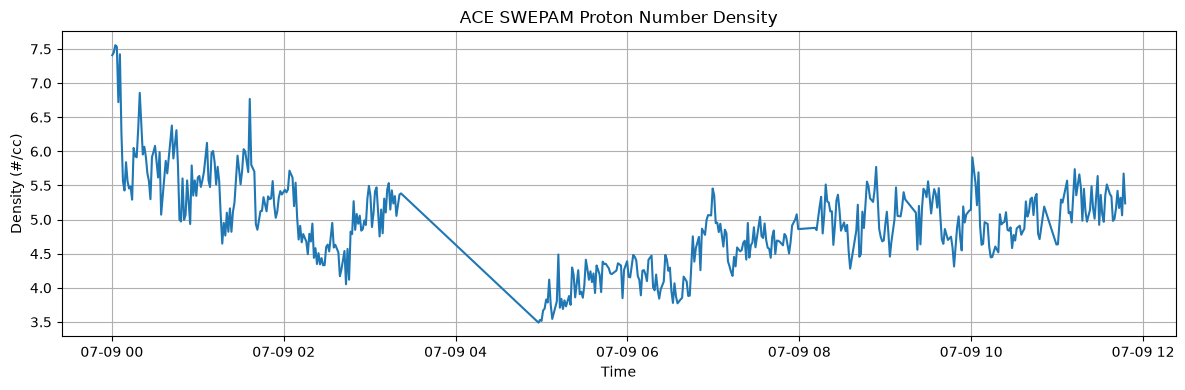

In [12]:
plt.figure(figsize=(12, 4))
plt.plot(time_np, density)
plt.title("ACE SWEPAM Proton Number Density")
plt.xlabel("Time")
plt.ylabel(f"Density ({density_atts.get('UNITS', '')})")
plt.grid(True)
plt.tight_layout()
plt.show()


In [13]:
density = np.asarray(cdf.varget("Np"))
atts = cdf.varattsget("Np")

fill = atts.get("FILLVAL")

print("Fill value:", fill)
print("Number of fill values:", np.sum(density == fill))

Fill value: -1e+31
Number of fill values: 868


In [14]:
missing = np.where(density == fill)[0]
print("Number of missing values:", len(missing))
print(missing[:20])

Number of missing values: 868
[ 19  29  33  37  38  41  50  61  81  88  92  96 100 112 117 126 143 147
 151 174]


In [17]:
density = np.asarray(cdf.varget("Np"), dtype=float)
density_atts = cdf.varattsget("Np")
times = cdflib.cdfepoch.to_datetime(cdf.varget("Epoch"))

fill_value = density_atts.get("FILLVAL")
valid_min = density_atts.get("VALIDMIN")
valid_max = density_atts.get("VALIDMAX")

mask = np.isfinite(density)

if fill_value is not None:
    mask &= density != fill_value

if valid_min is not None:
    mask &= density >= valid_min

if valid_max is not None:
    mask &= density <= valid_max

clean_times = times[mask]
clean_density = density[mask]

time_diff = np.diff(clean_times).astype('timedelta64[s]').astype(int)

print("Largest gap:", np.max(time_diff))

Largest gap: 5760


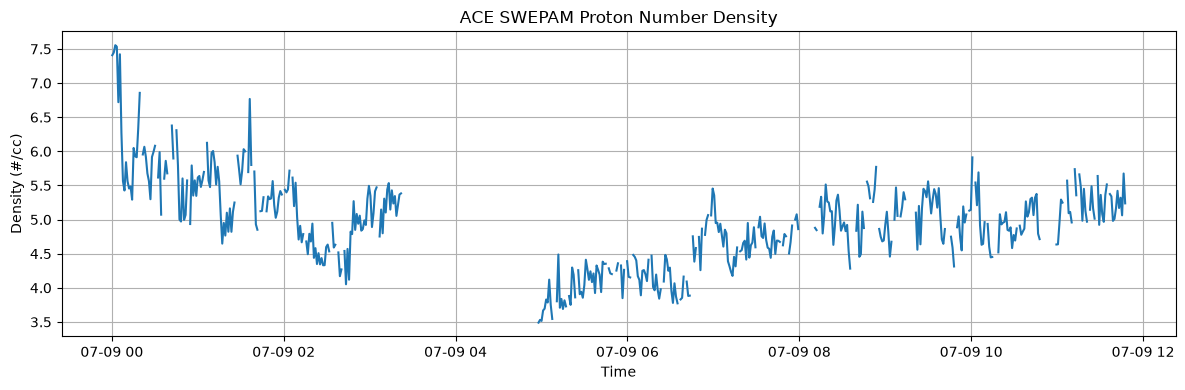

In [18]:
density_plot = density.copy()
density_plot[~mask] = np.nan

plt.figure(figsize=(12, 4))
plt.plot(times, density_plot)
plt.title("ACE SWEPAM Proton Number Density")
plt.xlabel("Time")
plt.ylabel("Density (#/cc)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
print("Minimum:", np.nanmin(speed))
print("Maximum:", np.nanmax(speed))
print("Mean:", np.nanmean(speed))
print("Standard Deviation:", np.nanstd(speed))


Minimum: 352.83
Maximum: 396.56
Mean: 375.6017
Standard Deviation: 7.7627134
